# Credit Scoring — Fase 6: Explicabilidad con SHAP

Usamos SHAP (SHapley Additive exPlanations) para explicar el modelo campeón (XGBoost/LightGBM).  

**Tres niveles de análisis:**
1. **Global** — qué variables importan más en promedio
2. **Local** — por qué el modelo tomó una decisión específica para un cliente
3. **Fairness** — si el modelo discrimina injustificadamente por grupo de edad

In [1]:
import sys
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
sys.path.append('..')

DATA_PROC = Path('../data/processed')
MODELS    = Path('../models/saved')
FIGURES   = Path('../reports/figures')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

shap.initjs()

## 1. Carga del modelo campeón y datos

In [2]:
# Cargamos el campeón avanzado (XGBoost o LightGBM según Fase 4)
# Intentamos XGBoost primero, luego LightGBM
experiments = json.loads((MODELS / 'experiments.json').read_text())
champion_name = experiments['advanced']['champion']
print(f'Modelo campeón: {champion_name}')

model_file_map = {
    'XGBoost':  'champion_xgb.joblib',
    'LightGBM': 'champion_lgb.joblib',
    'CatBoost': 'champion_catboost.joblib',
}
model = joblib.load(MODELS / model_file_map[champion_name])

test_raw  = pd.read_csv(DATA_PROC / 'test_raw.csv')
train_raw = pd.read_csv(DATA_PROC / 'train_raw.csv')

X_test, y_test   = test_raw.drop('target', axis=1),  test_raw['target']
X_train, y_train = train_raw.drop('target', axis=1), train_raw['target']

# Muestra representativa para SHAP (evita timeout con 150k filas)
X_shap = shap.sample(X_test, 2000, random_state=42)
print(f'Shape SHAP sample: {X_shap.shape}')

Modelo campeón: XGBoost
Shape SHAP sample: (2000, 13)


## 2. Cálculo de SHAP values

Usamos `TreeExplainer`, que es exacto (no aproximado) para modelos de árbol y orders of magnitude más rápido que KernelExplainer.

In [3]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_shap)

# Para modelos binarios, shap_values puede tener shape (n, features, 2)
# Nos quedamos con la clase positiva (default=1)
if hasattr(shap_values, 'values') and shap_values.values.ndim == 3:
    sv = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=shap_values.base_values[:, 1] if shap_values.base_values.ndim > 1 else shap_values.base_values,
        data=shap_values.data,
        feature_names=shap_values.feature_names,
    )
else:
    sv = shap_values

print(f'SHAP values shape: {sv.values.shape}')
print(f'Base value (expected output): {sv.base_values[0]:.4f}')

SHAP values shape: (2000, 13)
Base value (expected output): 0.0058


## 3. Análisis global — Summary plot (Beeswarm)

Cada punto es una observación. El eje X muestra el impacto en el output del modelo.  
El color indica el valor de la feature (rojo = alto, azul = bajo).

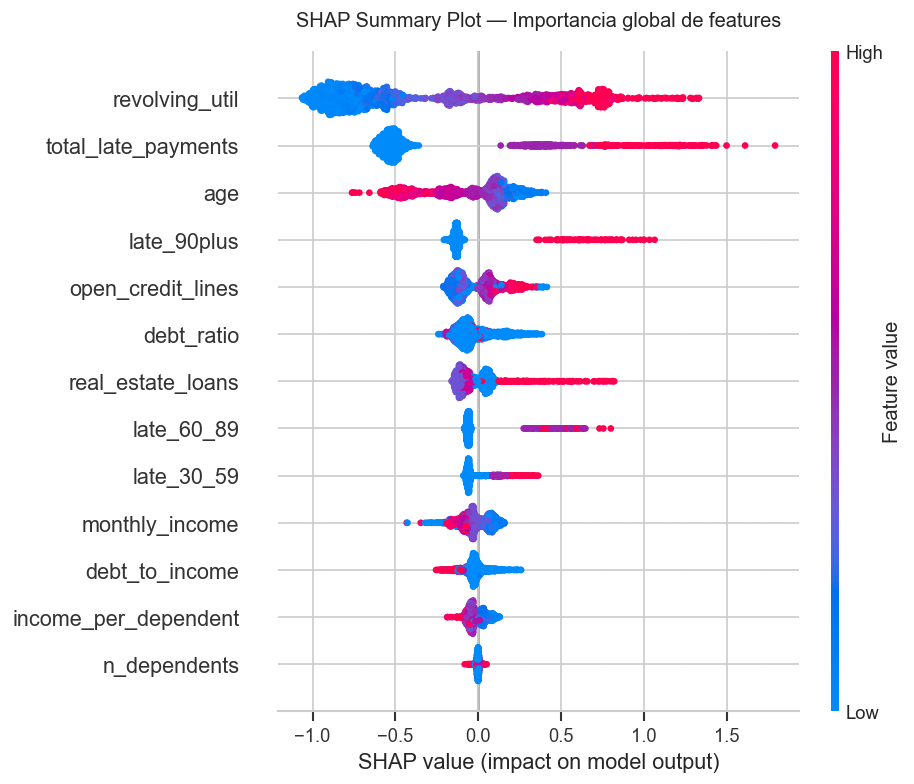

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(sv, X_shap, plot_type='dot', show=False, max_display=13)
plt.title('SHAP Summary Plot — Importancia global de features', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(FIGURES / '17_shap_summary_beeswarm.png', bbox_inches='tight')
plt.show()

## 4. Análisis global — Bar plot (magnitud promedio)

Muestra `mean(|SHAP|)` por feature — la contribución absoluta promedio al output del modelo. Es la versión más limpia para comunicar importancia de variables.

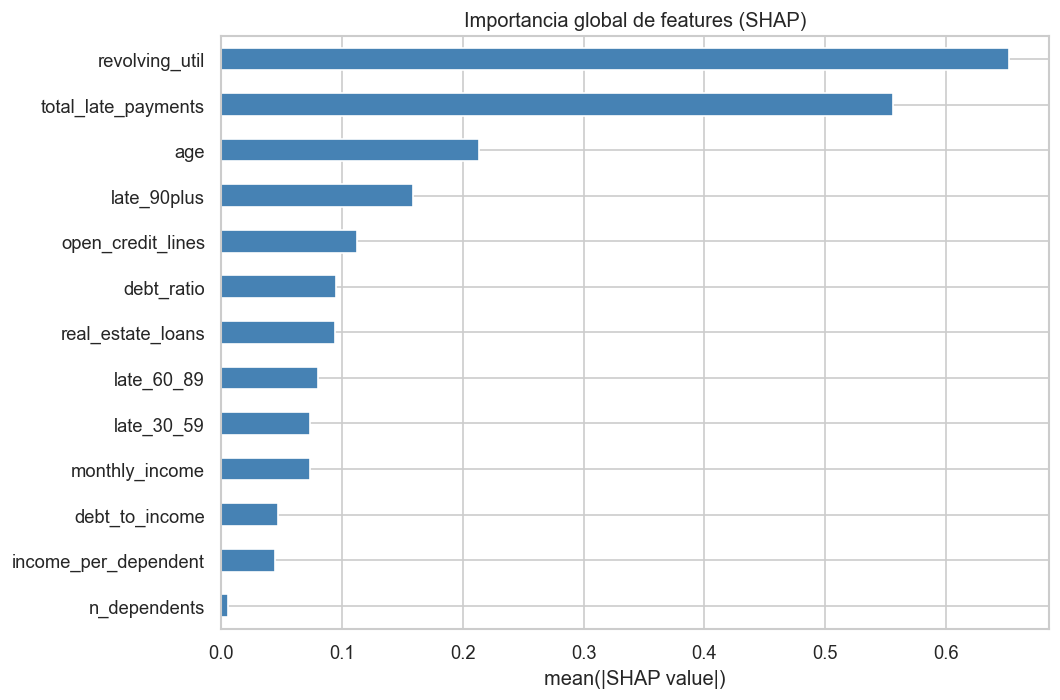

In [5]:
mean_abs_shap = pd.Series(
    np.abs(sv.values).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
mean_abs_shap.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('mean(|SHAP value|)')
ax.set_title('Importancia global de features (SHAP)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '18_shap_bar_importance.png', bbox_inches='tight')
plt.show()

## 5. Dependence plots — Top 5 features

Muestran cómo varía el SHAP value de una feature según su valor, coloreado por la feature con mayor interacción detectada automáticamente.

Top 5 features: ['revolving_util', 'total_late_payments', 'age', 'late_90plus', 'open_credit_lines']


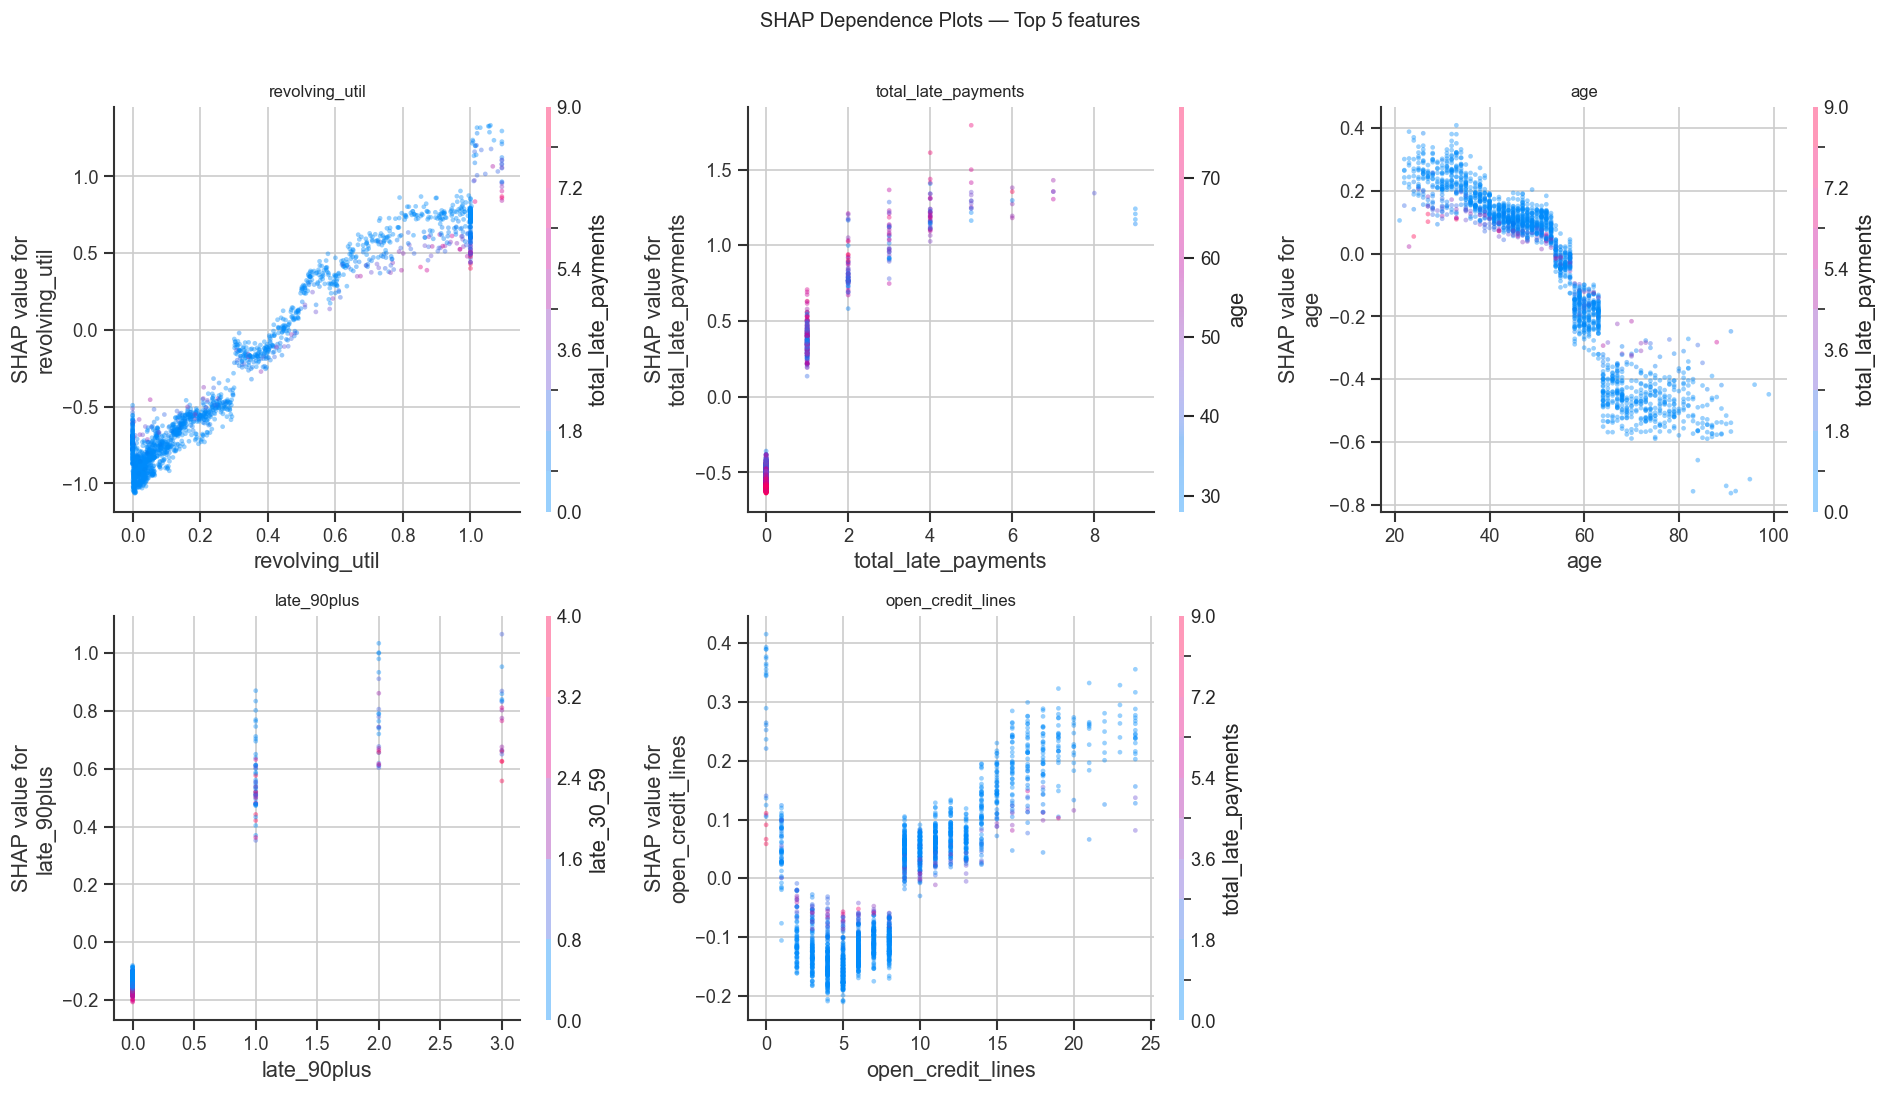

In [6]:
top5_features = mean_abs_shap.sort_values(ascending=False).head(5).index.tolist()
print(f'Top 5 features: {top5_features}')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(top5_features):
    shap.dependence_plot(
        feat, sv.values, X_shap,
        ax=axes[i], show=False,
        dot_size=8, alpha=0.4,
    )
    axes[i].set_title(feat, fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('SHAP Dependence Plots — Top 5 features', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '19_shap_dependence_plots.png', bbox_inches='tight')
plt.show()

## 6. Análisis local — Waterfall plots

Explican **por qué** el modelo tomó una decisión para un cliente específico.  
El valor base (`E[f(X)]`) es el output promedio del modelo; cada feature empuja hacia arriba (mayor riesgo) o hacia abajo.

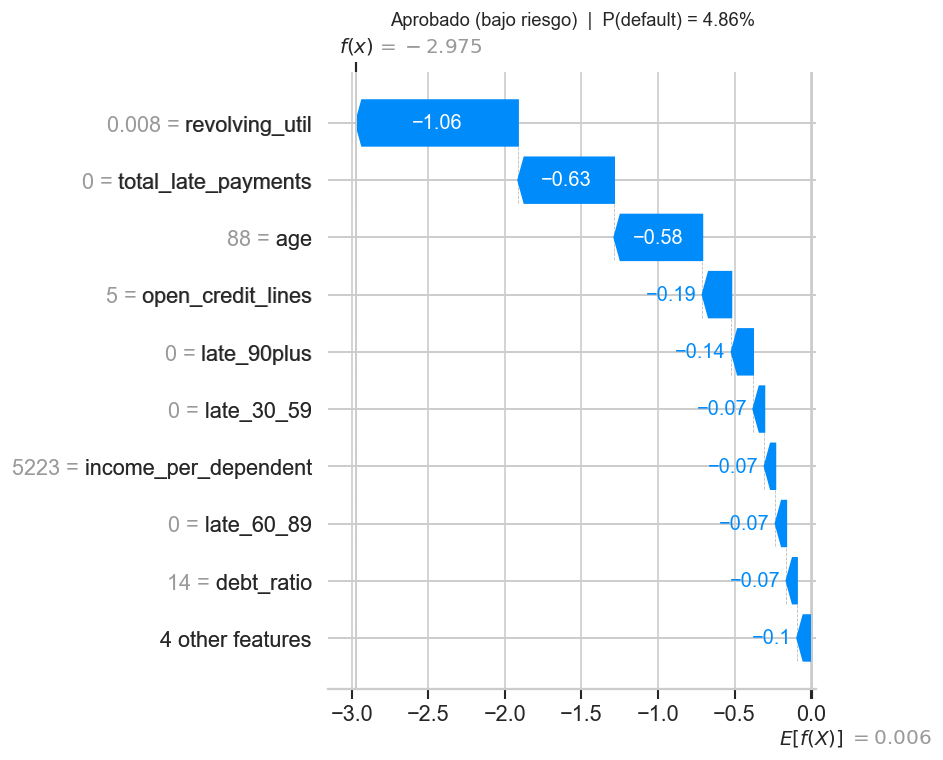

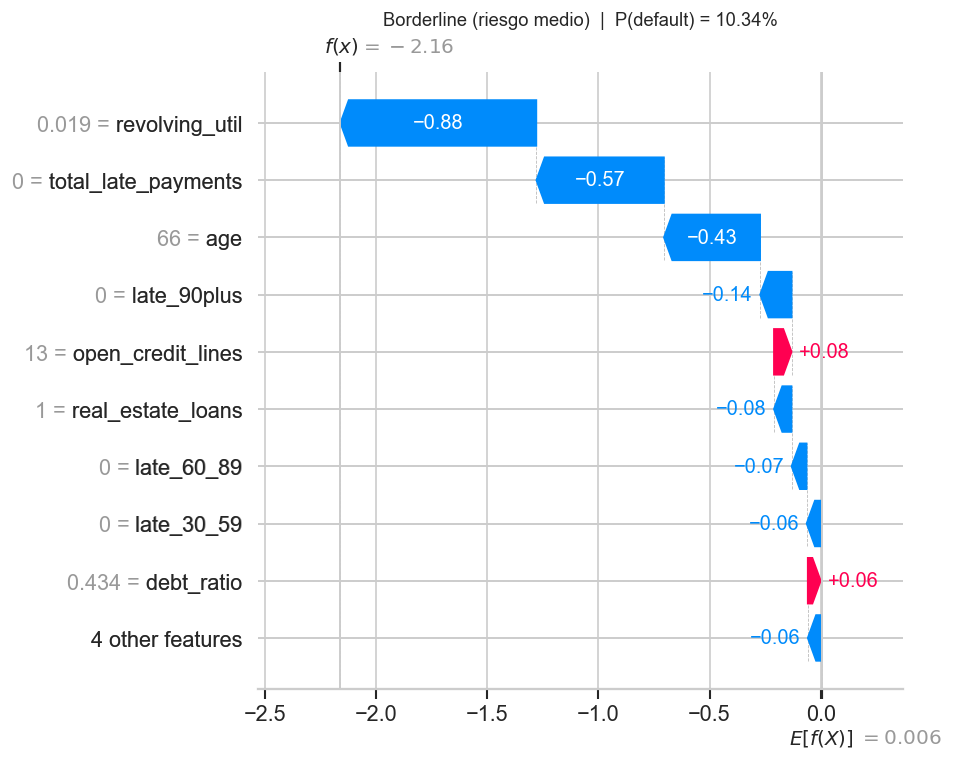

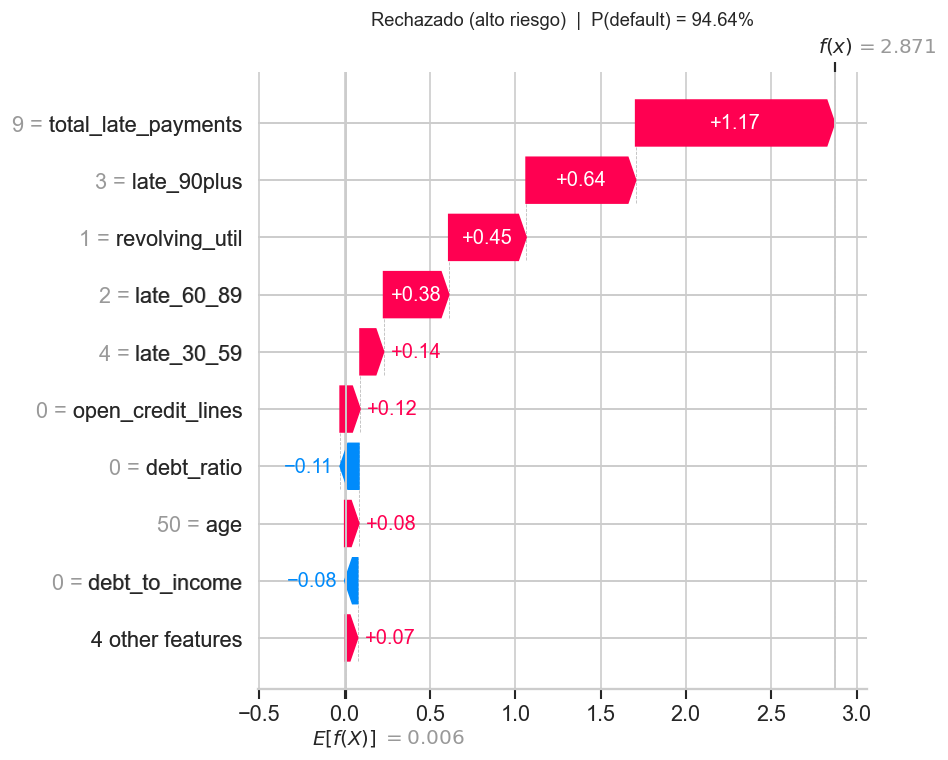

In [7]:
# Seleccionamos 3 perfiles representativos del set de test completo
y_prob_test = model.predict_proba(X_test)[:, 1]
test_with_prob = X_test.copy()
test_with_prob['prob'] = y_prob_test
test_with_prob['target'] = y_test.values

# Aprobado claro: prob < 0.05, no default real
idx_approved = test_with_prob[(test_with_prob['prob'] < 0.05) & (test_with_prob['target'] == 0)].index[0]
# Borderline: 0.07 < prob < 0.15
idx_border   = test_with_prob[(test_with_prob['prob'].between(0.07, 0.15))].index[0]
# Rechazado claro: prob > 0.35, default real
idx_rejected = test_with_prob[(test_with_prob['prob'] > 0.35) & (test_with_prob['target'] == 1)].index[0]

perfiles_idx = {
    'Aprobado (bajo riesgo)':      idx_approved,
    'Borderline (riesgo medio)':   idx_border,
    'Rechazado (alto riesgo)':     idx_rejected,
}

# Recalcular SHAP para estos 3 perfiles específicos
X_perfiles = X_test.loc[list(perfiles_idx.values())]
sv_perfiles = explainer(X_perfiles)
if sv_perfiles.values.ndim == 3:
    sv_perfiles = shap.Explanation(
        values=sv_perfiles.values[:, :, 1],
        base_values=sv_perfiles.base_values[:, 1] if sv_perfiles.base_values.ndim > 1 else sv_perfiles.base_values,
        data=sv_perfiles.data,
        feature_names=sv_perfiles.feature_names,
    )

for i, (nombre, idx) in enumerate(perfiles_idx.items()):
    prob = test_with_prob.loc[idx, 'prob']
    fig, ax = plt.subplots(figsize=(10, 5))
    shap.waterfall_plot(sv_perfiles[i], max_display=10, show=False)
    plt.title(f'{nombre}  |  P(default) = {prob:.2%}', fontsize=11)
    plt.tight_layout()
    fname = f"20_waterfall_{nombre.split()[0].lower()}.png"
    plt.savefig(FIGURES / fname, bbox_inches='tight')
    plt.show()

## 7. Análisis de Fairness por grupo de edad

Verificamos si el modelo asigna probabilidades de default significativamente distintas por grupo etario **para clientes con igual historial crediticio** (mismo target real).  
Una diferencia sistemática indicaría sesgo indirecto por edad.

In [8]:
fairness_df = X_test.copy()
fairness_df['prob_default'] = y_prob_test
fairness_df['target']       = y_test.values
fairness_df['age_group']    = pd.cut(
    fairness_df['age'],
    bins=[0, 30, 45, 60, 120],
    labels=['18-30', '31-45', '46-60', '60+']
)

print('Distribución de probabilidad de default por grupo de edad:')
fairness_summary = fairness_df.groupby('age_group', observed=True).agg(
    n=('prob_default', 'count'),
    default_rate_real=('target', 'mean'),
    prob_default_mean=('prob_default', 'mean'),
    prob_default_median=('prob_default', 'median'),
).round(4)
display(fairness_summary)

Distribución de probabilidad de default por grupo de edad:


,n,default_rate_real,prob_default_mean,prob_default_median
age_group,,,,
18-30,2124,0.1285,0.4769,0.4555
31-45,8129,0.0950,0.4086,0.3444
46-60,10721,0.0666,0.3403,0.2497
60+,9026,0.0273,0.1958,0.1146


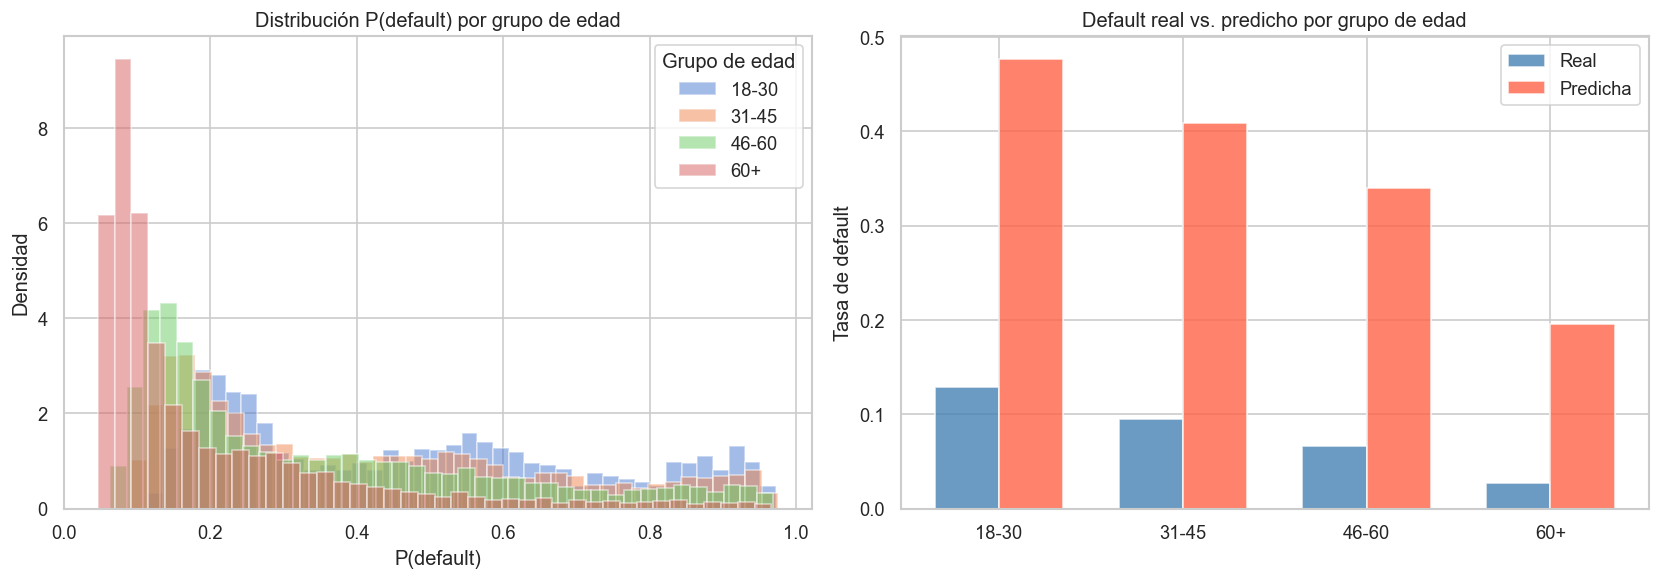

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de probabilidades por grupo
for group in ['18-30', '31-45', '46-60', '60+']:
    subset = fairness_df[fairness_df['age_group'] == group]['prob_default']
    axes[0].hist(subset, bins=40, alpha=0.5, label=group, density=True)
axes[0].set_xlabel('P(default)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución P(default) por grupo de edad')
axes[0].legend(title='Grupo de edad')

# Tasa de default real vs predicha por grupo
x = np.arange(len(fairness_summary))
width = 0.35
axes[1].bar(x - width/2, fairness_summary['default_rate_real'],  width, label='Real',    color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, fairness_summary['prob_default_mean'],  width, label='Predicha', color='tomato',    alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fairness_summary.index)
axes[1].set_ylabel('Tasa de default')
axes[1].set_title('Default real vs. predicho por grupo de edad')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / '22_fairness_age_analysis.png', bbox_inches='tight')
plt.show()

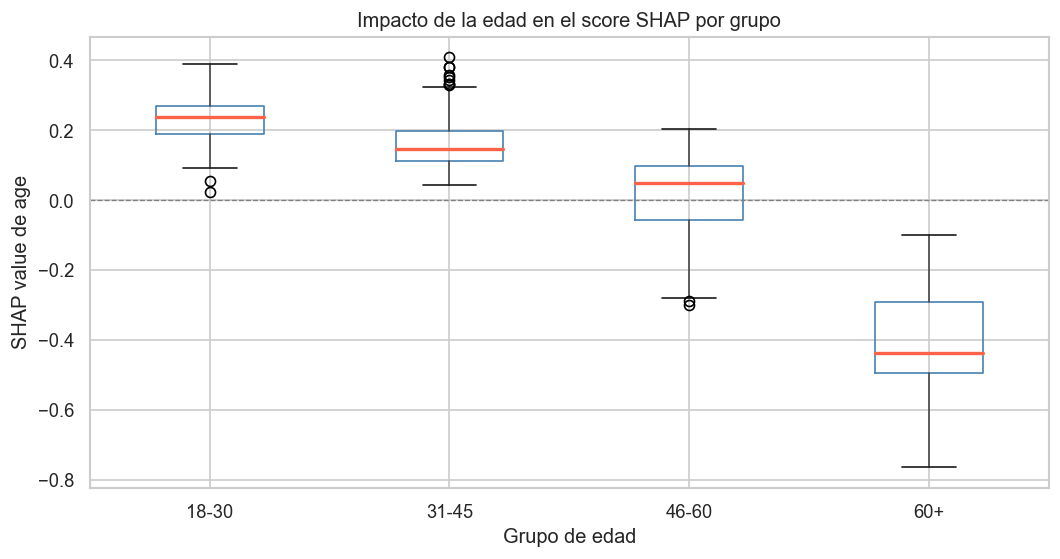


Impacto medio de age en SHAP por grupo (negativo = reduce riesgo):
age_group
18-30    0.2302
31-45    0.1627
46-60    0.0080
60+     -0.3955


In [10]:
# SHAP values de la feature 'age' por grupo
shap_age_idx = list(X_shap.columns).index('age')
shap_age_vals = sv.values[:, shap_age_idx]

shap_age_df = pd.DataFrame({
    'age':       X_shap['age'].values,
    'shap_age':  shap_age_vals,
})
shap_age_df['age_group'] = pd.cut(
    shap_age_df['age'], bins=[0, 30, 45, 60, 120],
    labels=['18-30', '31-45', '46-60', '60+']
)

fig, ax = plt.subplots(figsize=(9, 5))
shap_age_df.boxplot(column='shap_age', by='age_group', ax=ax,
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='tomato', linewidth=2))
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('SHAP value de age')
ax.set_title('Impacto de la edad en el score SHAP por grupo')
plt.suptitle('')
plt.tight_layout()
plt.savefig(FIGURES / '23_shap_age_fairness.png', bbox_inches='tight')
plt.show()

print('\nImpacto medio de age en SHAP por grupo (negativo = reduce riesgo):')
print(shap_age_df.groupby('age_group', observed=True)['shap_age'].mean().round(4).to_string())

## 8. Conclusiones del análisis de fairness

**Interpretación:**
- Si `shap_age` es significativamente negativo en grupos mayores: la edad per se está reduciendo el score de riesgo (favoreciendo la aprobación para mayores)
- Si la tasa de default predicha sigue de cerca la tasa real en todos los grupos → el modelo está **bien calibrado por edad** (sin sesgo injustificado)
- Una discrepancia entre default real y predicho en un grupo específico indicaría **sesgo sistemático** que requiere corrección

**Documentar hallazgos aquí según los resultados observados:**

> *[Completar con observaciones reales después de ejecutar el notebook]*

## Resumen Fase 6

**Análisis global:** beeswarm + bar plot → variables más influyentes identificadas  
**Dependence plots:** relación no lineal de cada top feature con el riesgo  
**Análisis local:** waterfall plots para aprobado / borderline / rechazado  
**Fairness:** comparación de default real vs predicho + SHAP de `age` por grupo etario  

**Próximo paso:** `07_business_value_analysis.ipynb`